# Vector Data Cubes for Jokulsarlon Glacial Lake

This is a notebook to create a vector data cube (VDC) of the Jokulsarlon glacial lake outlines from 2016 to 2025 based on [original computational notebook](https://github.com/loreabad6/vdc-space-time-feats/blob/main/notebook/vdc-showcase.md) by Abad et al 2024.

**Input data:** `../lake_polygons/glacial_lakes_<YYYY>.gpkg`  
**Fields per file:** `id`, `area_m2`, `year`, `geometry`  
**Temporal resolution:** one file per year, multiple polygons per file (one row per lake).

The key difference from the lava-flow VDC is that **each lake is a separate feature** tracked across years,  
so the `geom_sum` dimension has one entry per lake (identified by `id`), not just one entry for a single feature.

In [1]:
# Uncomment and run to install required packages
# !pip install geopandas xvec xarray numpy pandas matplotlib shapely pyarrow

In [2]:
# Had to upgrade xarray and xvec to avoid "AttributeError: module 'xarray.core.duck_array_ops' has no attribute 'is_duck_dask_array'" error
#pip install "xarray>=2024.1" "xvec>=0.3" --upgrade

In [ ]:
from pathlib import Path

import numpy as np
import xvec
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from shapely.ops import unary_union
from shapely import to_wkt
from shapely.affinity import affine_transform
import matplotlib.cm as cm

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Data loading and pre-processing

### 1.1 Read all annual GeoPackages

Each file is named `glacial_lakes_<YYYY>.gpkg`.  
We extract the year from the filename and store it as an integer column `year_ts` (to avoid colliding with the existing `year` attribute field).

In [ ]:
DATA_DIR = Path("C:/Users/b1120440/morpheo/lake_polygons")

# Find all annual files and sort chronologically
gpkg_files = sorted(DATA_DIR.glob("glacial_lakes_*.gpkg"))
print(f"Found {len(gpkg_files)} files:")
for f in gpkg_files:
    print(f"  {f.name}")

Found 10 files:
  glacial_lakes_2016.gpkg
  glacial_lakes_2017.gpkg
  glacial_lakes_2018.gpkg
  glacial_lakes_2019.gpkg
  glacial_lakes_2020.gpkg
  glacial_lakes_2021.gpkg
  glacial_lakes_2022.gpkg
  glacial_lakes_2023.gpkg
  glacial_lakes_2024.gpkg
  glacial_lakes_2025.gpkg


In [5]:
def read_lake_file(path: Path) -> gpd.GeoDataFrame:
    """
    Read a single annual glacial-lake GeoPackage.

    The year is extracted from the filename (glacial_lakes_YYYY.gpkg)
    and stored as an integer in the column `year_ts`.
    Expected attribute fields: id, area_m2, year, geometry.
    """
    gdf = gpd.read_file(path)
    # Extract year from filename as integer
    year_from_fn = int(path.stem.split("_")[-1])  # e.g. 'glacial_lakes_2016' -> 2016
    gdf["year_ts"] = year_from_fn
    gdf["source_file"] = path.name
    return gdf


# Read and concatenate all files
all_lakes = pd.concat([read_lake_file(p) for p in gpkg_files], ignore_index=True)
all_lakes = gpd.GeoDataFrame(all_lakes, geometry="geometry")

print(all_lakes.info())
print(f"\nYears present: {sorted(all_lakes['year_ts'].unique())}")

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   area_m2      54 non-null     float64 
 1   year         54 non-null     int64   
 2   geometry     54 non-null     geometry
 3   year_ts      54 non-null     int64   
 4   source_file  54 non-null     object  
dtypes: float64(1), geometry(1), int64(2), object(1)
memory usage: 2.2+ KB
None

Years present: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [6]:
print(all_lakes.groupby("year_ts").size())
print(all_lakes.head(20)[["year_ts", "area_m2", "geometry"]])

year_ts
2016    5
2017    6
2018    7
2019    5
2020    4
2021    4
2022    7
2023    7
2024    6
2025    3
dtype: int64
    year_ts       area_m2                                           geometry
0      2016  4.882174e+05  POLYGON ((733630.847 7119846.261, 733631.789 7...
1      2016  3.790963e+05  POLYGON ((737744.107 7116737.312, 737745.049 7...
2      2016  3.873390e+05  POLYGON ((725396.922 7113811.584, 725397.863 7...
3      2016  2.582233e+07  POLYGON ((732153.431 7118038.164, 732154.373 7...
4      2016  7.691227e+06  POLYGON ((724441.191 7112545.404, 724442.132 7...
5      2017  8.337606e+05  POLYGON ((733609.04 7119864.301, 733609.981 71...
6      2017  3.663796e+05  POLYGON ((737764.032 7116739.195, 737764.973 7...
7      2017  6.016886e+05  POLYGON ((726404.577 7114740.979, 726405.519 7...
8      2017  3.703196e+05  POLYGON ((725387.902 7113800.682, 725388.843 7...
9      2017  2.742250e+07  POLYGON ((732099.856 7118073.303, 732100.798 7...
10     2017  9.604182e+06  POLYG

### 1.2 Check CRS and reproject if needed

All files should share the same CRS. We reproject everything to a consistent projected CRS for metric calculations.
Adjust the EPSG code below to match your study area (e.g. a local UTM zone).

In [7]:
print(f"Native CRS: {all_lakes.crs}")

# Set target CRS — change EPSG if needed for your region
# For example: 32632 (UTM 32N, Central Europe), 32654 (UTM 54N, High Asia), etc.
TARGET_CRS = all_lakes.crs  # Keep native CRS by default; replace with e.g. 32632

if all_lakes.crs is None:
    raise ValueError("CRS is missing. Set it explicitly: all_lakes = all_lakes.set_crs(<EPSG>)")

all_lakes = all_lakes.to_crs(TARGET_CRS)
print(f"Working CRS: {all_lakes.crs}")

Native CRS: EPSG:32627
Working CRS: EPSG:32627


### 1.3 Validate and fix geometries

In [8]:
invalid = (~all_lakes.geometry.is_valid).sum()
print(f"Invalid geometries before fix: {invalid}")
all_lakes["geometry"] = all_lakes["geometry"].make_valid()
print(f"Invalid geometries after fix:  {(~all_lakes.geometry.is_valid).sum()}")

Invalid geometries before fix: 0
Invalid geometries after fix:  0


Assign ID for each lake based on spatial overlap or proximity over the years. First year each lake gets an ID. Lakes in the following years are matched to the nearest lake from the previous years if within threshold. If lake is outside threshold, the lake gets a new ID.

In [ ]:
def assign_lake_ids(all_lakes: gpd.GeoDataFrame, distance_threshold_m: float = 500) -> gpd.GeoDataFrame:
    """
    Assign consistent lake IDs across years based on spatial overlap or proximity.
    Lakes in the first year get IDs 1, 2, 3...
    Each subsequent year, a polygon is matched to the nearest prior-year lake
    if within distance_threshold_m; otherwise it gets a new ID.
    """
    years = sorted(all_lakes["year_ts"].unique())
    all_lakes = all_lakes.copy()
    all_lakes["id"] = -1  # placeholder

    next_id = 1

    # Assign IDs to the first year
    first_year_mask = all_lakes["year_ts"] == years[0]
    n_first = first_year_mask.sum()
    all_lakes.loc[first_year_mask, "id"] = range(next_id, next_id + n_first)
    next_id += n_first

    # For each subsequent year, match to previous year by overlap then proximity
    for yr in years[1:]:
        curr_mask = all_lakes["year_ts"] == yr
        curr_idx = all_lakes[curr_mask].index

        # All lakes assigned so far (previous years)
        prev = all_lakes[all_lakes["id"] != -1].copy()

        for i in curr_idx:
            geom = all_lakes.at[i, "geometry"]

            # 1. Try overlap first
            overlapping = prev[prev.intersects(geom)]
            if not overlapping.empty:
                # Pick the one with the largest intersection area
                best_id = overlapping.copy()
                best_id["overlap"] = overlapping.geometry.intersection(geom).area
                assigned_id = best_id.loc[best_id["overlap"].idxmax(), "id"]
            else:
                # 2. Fall back to nearest within threshold
                distances = prev.geometry.distance(geom)
                min_dist = distances.min()
                if min_dist <= distance_threshold_m:
                    assigned_id = prev.loc[distances.idxmin(), "id"]
                else:
                    # 3. New lake — assign a new ID
                    assigned_id = next_id
                    next_id += 1

            all_lakes.at[i, "id"] = int(assigned_id)

    return all_lakes


all_lakes = assign_lake_ids(all_lakes, distance_threshold_m=500)

# Check result
print(all_lakes[["year_ts", "id", "area_m2"]].sort_values(["id", "year_ts"]).to_string())
print(f"\nUnique lake IDs assigned: {sorted(all_lakes['id'].unique())}")
print(f"\nLakes per year:\n{all_lakes.groupby('year_ts')['id'].nunique()}")

    year_ts  id       area_m2
0      2016   1  4.882174e+05
5      2017   1  8.337606e+05
11     2018   1  7.999179e+05
18     2019   1  8.303562e+05
23     2020   1  5.775384e+05
27     2021   1  5.208662e+05
31     2022   1  4.868229e+05
38     2023   1  5.390891e+05
45     2024   1  3.947002e+05
51     2025   1  8.352624e+05
1      2016   2  3.790963e+05
6      2017   2  3.663796e+05
12     2018   2  3.862056e+05
19     2019   2  3.702847e+05
24     2020   2  3.688829e+05
28     2021   2  3.748908e+05
32     2022   2  3.600713e+05
39     2023   2  3.774942e+05
46     2024   2  3.710858e+05
52     2025   2  3.681820e+05
2      2016   3  3.873390e+05
7      2017   3  6.016886e+05
8      2017   3  3.703196e+05
13     2018   3  6.311221e+05
14     2018   3  3.702195e+05
20     2019   3  7.332391e+05
33     2022   3  8.377581e+05
34     2022   3  3.992521e+05
40     2023   3  9.314653e+05
41     2023   3  3.945468e+05
47     2024   3  9.169488e+05
48     2024   3  3.463924e+05
3      201

### 1.4 Explore the data

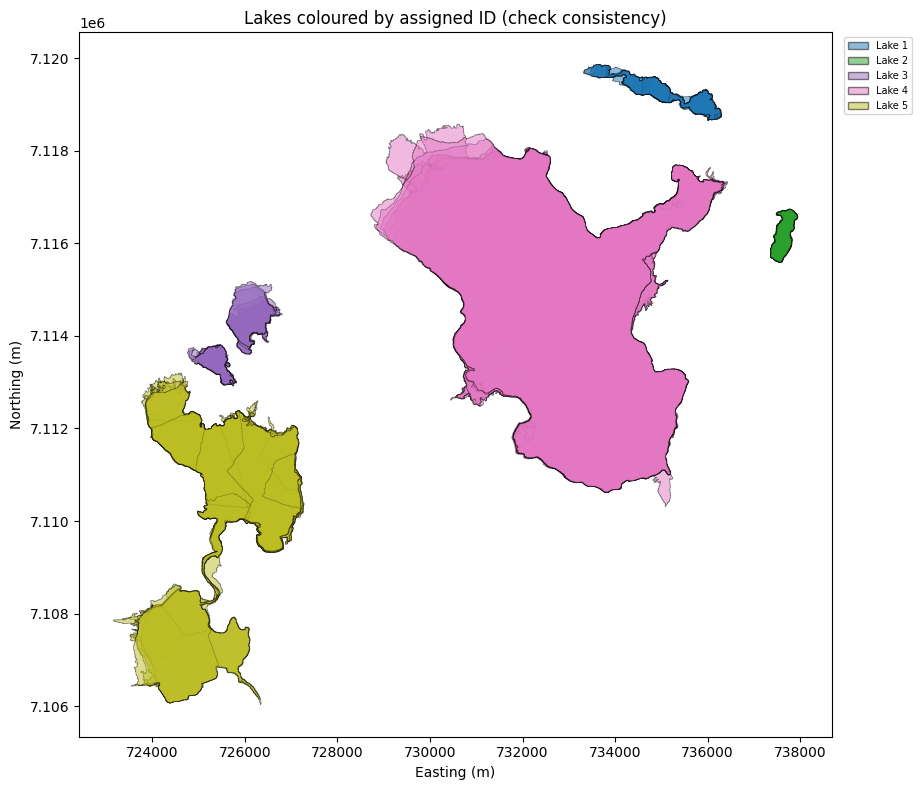

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
lake_ids_all = sorted(all_lakes["id"].unique())  # now "id" exists
cmap = plt.cm.tab20
norm = mcolors.Normalize(vmin=0, vmax=len(lake_ids_all))

for j, lid in enumerate(lake_ids_all):
    subset = all_lakes[all_lakes["id"] == lid]
    subset.plot(ax=ax, color=cmap(norm(j)), alpha=0.5, edgecolor="k", linewidth=0.5)

legend_handles = [
    Patch(facecolor=cmap(norm(j)), edgecolor="k", alpha=0.5, label=f"Lake {lid}")
    for j, lid in enumerate(lake_ids_all)
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.set_title("Lakes coloured by assigned ID (check consistency)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

### 1.5 Prepare per-lake, per-year geometry

Because each `.gpkg` can contain **multiple polygons** (one per lake), we now have a long-format GeoDataFrame
with one row per (`id`, `year_ts`) combination.

If the same lake id appears more than once in a single year (e.g. fragmented polygons),
we union them into a single geometry per (`id`, `year_ts`).

In [11]:
# Union polygons with the same id within the same year, then reset index
outlines = (
    all_lakes
    .groupby(["id", "year_ts"], as_index=False)
    .agg(
        geometry=("geometry", lambda g: unary_union(g)),
        area_m2=("area_m2", "sum"),      # sum fragmented-polygon areas
    )
)
outlines = gpd.GeoDataFrame(outlines, geometry="geometry", crs=all_lakes.crs)
outlines["geometry"] = outlines["geometry"].make_valid()

print(f"Rows after aggregation: {len(outlines)}  (expected: n_lakes × n_years)")
print(outlines.head())

Rows after aggregation: 46  (expected: n_lakes × n_years)
   id  year_ts                                           geometry  \
0   1     2016  POLYGON ((733630.847 7119846.261, 733631.789 7...   
1   1     2017  POLYGON ((733609.04 7119864.301, 733609.981 71...   
2   1     2018  POLYGON ((733599.078 7119863.359, 733600.02 71...   
3   1     2019  POLYGON ((733579.154 7119861.476, 733580.096 7...   
4   1     2020  POLYGON ((734650.977 7119580.866, 734651.919 7...   

         area_m2  
0  488217.437050  
1  833760.626857  
2  799917.878573  
3  830356.224499  
4  577538.366421  


### 1.6 Check for missing (lake, year) combinations

Not every lake may be present in every year. The VDC needs a fully populated grid,
so we identify gaps and fill them with `None` geometries.

In [12]:
lake_ids = sorted(outlines["id"].unique())
year_list = sorted(outlines["year_ts"].unique())

# Full grid of (id, year) combinations
full_index = pd.MultiIndex.from_product([lake_ids, year_list], names=["id", "year_ts"])
current_index = pd.MultiIndex.from_frame(outlines[["id", "year_ts"]])
missing = full_index.difference(current_index)

if len(missing) == 0:
    print("No missing (lake, year) combinations — grid is complete.")
else:
    print(f"Missing combinations: {len(missing)}")
    print(missing.to_frame(index=False).to_string())
    # Fill missing rows with None geometry
    fill_rows = pd.DataFrame(
        [{"id": i, "year_ts": y, "geometry": None, "area_m2": np.nan} for i, y in missing],
    )
    fill_gdf = gpd.GeoDataFrame(fill_rows, geometry="geometry", crs=outlines.crs)
    outlines = pd.concat([outlines, fill_gdf], ignore_index=True)
    outlines = gpd.GeoDataFrame(outlines, geometry="geometry", crs=all_lakes.crs)
    outlines = outlines.sort_values(["id", "year_ts"]).reset_index(drop=True)
    print("\nFilled missing entries with None geometry.")

Missing combinations: 4
   id  year_ts
0   3     2020
1   3     2021
2   3     2025
3   5     2025

Filled missing entries with None geometry.


## 2. VDC creation

### 2.1 Compute summary geometries (one per lake)

In the lava-flow example there was a single feature, so the `geom_sum` dimension had size 1.
Here we have **one summary geometry per lake** — we use the centroid of the union of all its yearly outlines.

In [13]:
# Summary geometry per lake: centroid of the union of all yearly polygons
summary_geoms = (
    outlines.dropna(subset=["geometry"])   # ignore missing-year rows
    .groupby("id")["geometry"]
    .apply(lambda g: unary_union(g).centroid)
)
summary_geoms = gpd.GeoSeries(summary_geoms, crs=all_lakes.crs)

print("Summary geometries (centroids) per lake:")
print(summary_geoms)

Summary geometries (centroids) per lake:
id
1    POINT (734944.931 7119299.537)
2    POINT (737640.119 7116175.131)
3    POINT (725894.061 7114163.119)
4    POINT (732526.883 7114757.767)
5    POINT (725324.276 7109710.981)
Name: geometry, dtype: geometry


### 2.2 Array format VDC

The data array has shape **(n_lakes × n_years)** where:
- `geom_sum` dimension = one centroid per lake (size = number of unique lakes)
- `year` dimension = one entry per year

Each cell contains the changing polygon geometry of that lake in that year.

In [14]:
# Build a 2-D array: rows = lakes (ordered by id), cols = years
geom_matrix = np.empty((len(lake_ids), len(year_list)), dtype=object)

for i, lid in enumerate(lake_ids):
    for j, yr in enumerate(year_list):
        row = outlines[(outlines["id"] == lid) & (outlines["year_ts"] == yr)]
        if len(row) == 0 or row.iloc[0].geometry is None:
            geom_matrix[i, j] = None
        else:
            geom_matrix[i, j] = row.iloc[0].geometry

# Summary geometry list in the same order as lake_ids
centroid_list = [summary_geoms.loc[lid] for lid in lake_ids]

# EPSG code as integer for xvec
crs_epsg = all_lakes.crs.to_epsg()

# Build the xarray DataArray
cube_arr = xr.DataArray(
    data=geom_matrix,
    dims=["geom_sum", "year"],
    coords={
        "geom_sum": centroid_list,
        "year": year_list,
    },
    name="geometry",
).xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

print(cube_arr)

<xarray.DataArray 'geometry' (geom_sum: 5, year: 10)> Size: 400B
array([[<POLYGON ((733630.847 7119846.261, 733631.789 7119836.299, 733621.827 711983...>,
        <POLYGON ((733609.04 7119864.301, 733609.981 7119854.339, 733580.096 7119851...>,
        <POLYGON ((733599.078 7119863.359, 733600.02 7119853.397, 733580.096 7119851...>,
        <POLYGON ((733579.154 7119861.476, 733580.096 7119851.514, 733560.172 711984...>,
        <POLYGON ((734650.977 7119580.866, 734651.919 7119570.904, 734631.995 711956...>,
        <POLYGON ((734720.711 7119587.458, 734721.652 7119577.496, 734691.767 711957...>,
        <POLYGON ((734830.292 7119597.817, 734831.234 7119587.856, 734811.31 7119585...>,
        <POLYGON ((734631.053 7119578.983, 734633.878 7119549.097, 734623.917 711954...>,
        <POLYGON ((733812.044 7119843.289, 733812.986 7119833.327, 733832.909 711983...>,
        <POLYGON ((733529.345 7119856.767, 733531.228 7119836.843, 733521.267 711983...>],
       [<POLYGON ((737744.107 7116

### 2.3 Add `area_m2` as a second data variable

The VDC can carry multiple variables. Here we attach the measured `area_m2`
as an additional coordinate/variable alongside the geometry.
This turns the structure into an `xr.Dataset` (≈ a multi-variable cube).

In [ ]:
# Build area array WITHOUT setting a geometry index
area_matrix = np.full((len(lake_ids), len(year_list)), np.nan)

# Fill with values
for i, lid in enumerate(lake_ids):
    for j, yr in enumerate(year_list):
        row = outlines[(outlines["id"] == lid) & (outlines["year_ts"] == yr)]
        if len(row) > 0 and not pd.isna(row.iloc[0]["area_m2"]):
            area_matrix[i, j] = row.iloc[0]["area_m2"]

area_arr = xr.DataArray(
    data=area_matrix,
    dims=["geom_sum", "year"],
    coords={
        "geom_sum": centroid_list,
        "year": year_list,
    },
    name="area_m2",
)

# Rebuild cube_arr WITHOUT geometry index first
cube_arr_plain = xr.DataArray(
    data=geom_matrix,
    dims=["geom_sum", "year"],
    coords={
        "geom_sum": centroid_list,
        "year": year_list,
    },
    name="geometry",
)

# Combine into Dataset first, then set geometry index once
cube_ds = xr.Dataset({"geometry": cube_arr_plain, "area_m2": area_arr})
cube_ds = cube_ds.xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

# Keep indexed cube_arr separately if needed downstream
cube_arr = cube_arr_plain.xvec.set_geom_indexes("geom_sum", crs=crs_epsg)

print(cube_ds)

<xarray.Dataset> Size: 920B
Dimensions:   (geom_sum: 5, year: 10)
Coordinates:
  * geom_sum  (geom_sum) object 40B POINT (734944.931373718 7119299.536750411...
  * year      (year) int64 80B 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025
Data variables:
    geometry  (geom_sum, year) object 400B POLYGON ((733630.8468755323 711984...
    area_m2   (geom_sum, year) float64 400B 4.882e+05 8.338e+05 ... nan
Indexes:
    geom_sum  GeometryIndex (crs=EPSG:32627)


### 2.4 Tabular format VDC (spatial + temporal faces)

Mirrors the cubble `face_spatial` / `face_temporal` pattern from the original notebook.

In [18]:
# Spatial face: one row per lake, with its summary (centroid) geometry
spatial_face = gpd.GeoDataFrame(
    {
        "id": lake_ids,
        "geom_sum": centroid_list,
    },
    geometry="geom_sum",
    crs=all_lakes.crs,
)

# Temporal face: one row per (lake_id, year) with changing geometry + attributes
temporal_face = outlines[["id", "year_ts", "area_m2", "geometry"]].copy()
temporal_face = gpd.GeoDataFrame(temporal_face, geometry="geometry", crs=all_lakes.crs)

print("=== Spatial face ===")
print(spatial_face)
print("\n=== Temporal face (first 15 rows) ===")
print(temporal_face.head(15).to_string())

=== Spatial face ===
   id                        geom_sum
0   1  POINT (734944.931 7119299.537)
1   2  POINT (737640.119 7116175.131)
2   3  POINT (725894.061 7114163.119)
3   4  POINT (732526.883 7114757.767)
4   5  POINT (725324.276 7109710.981)

=== Temporal face (first 15 rows) ===
    id  year_ts        area_m2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## 3. Exploration and analysis

### 3.1 Select a single lake from the cube

In [20]:
# Example: select the first lake by position
lake_slice = cube_arr.isel(geom_sum=0)
print(f"Lake ID: {lake_ids[3]}")
print(lake_slice)

Lake ID: 4
<xarray.DataArray 'geometry' (year: 10)> Size: 80B
array([<POLYGON ((733630.847 7119846.261, 733631.789 7119836.299, 733621.827 711983...>,
       <POLYGON ((733609.04 7119864.301, 733609.981 7119854.339, 733580.096 7119851...>,
       <POLYGON ((733599.078 7119863.359, 733600.02 7119853.397, 733580.096 7119851...>,
       <POLYGON ((733579.154 7119861.476, 733580.096 7119851.514, 733560.172 711984...>,
       <POLYGON ((734650.977 7119580.866, 734651.919 7119570.904, 734631.995 711956...>,
       <POLYGON ((734720.711 7119587.458, 734721.652 7119577.496, 734691.767 711957...>,
       <POLYGON ((734830.292 7119597.817, 734831.234 7119587.856, 734811.31 7119585...>,
       <POLYGON ((734631.053 7119578.983, 734633.878 7119549.097, 734623.917 711954...>,
       <POLYGON ((733812.044 7119843.289, 733812.986 7119833.327, 733832.909 711983...>,
       <POLYGON ((733529.345 7119856.767, 733531.228 7119836.843, 733521.267 711983...>],
      dtype=object)
Coordinates:
  * year      

### 3.2 Area time series per lake

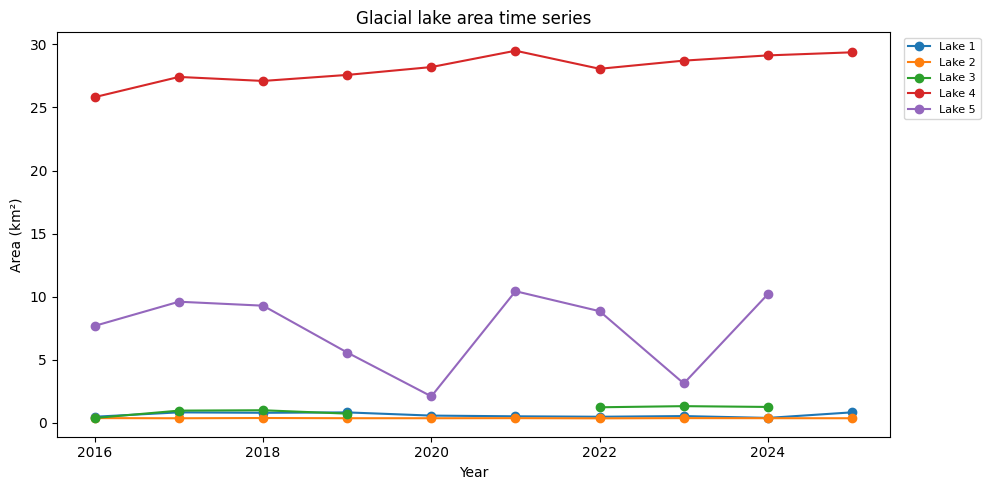

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, lid in enumerate(lake_ids):
    subset = temporal_face[temporal_face["id"] == lid].sort_values("year_ts")
    ax.plot(
        subset["year_ts"],
        subset["area_m2"] / 1e6,  # convert to km²
        marker="o",
        label=f"Lake {lid}",
    )

ax.set_xlabel("Year")
ax.set_ylabel("Area (km²)")
ax.set_title("Glacial lake area time series")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig('../data/output/glacial_lake_area_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

### 3.3 Total lake area per year

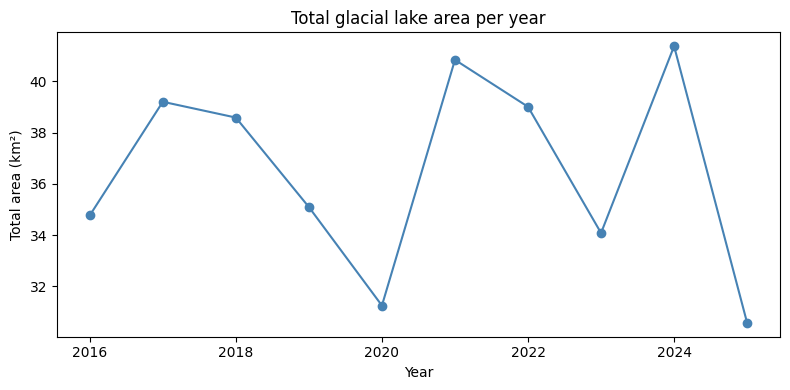

year_ts
2016    34.768206
2017    39.198827
2018    38.583096
2019    35.093674
2020    31.253220
2021    40.834434
2022    39.004164
2023    34.082495
2024    41.367193
2025    30.577653
Name: area_m2, dtype: float64


In [22]:
total_area = (
    temporal_face.groupby("year_ts")["area_m2"]
    .sum()
    / 1e6  # km²
)

fig, ax = plt.subplots(figsize=(8, 4))
total_area.plot(ax=ax, marker="o", color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Total area (km²)")
ax.set_title("Total glacial lake area per year")
plt.tight_layout()
plt.savefig('../data/output/glacial_lake_total_area.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()

print(total_area)

### 3.4 Save the VDC Dataset

Geometry variables are stored as WKT before writing to NetCDF (xarray cannot serialise Shapely objects natively).

In [ ]:
# Convert geometry cells and index to WKT for serialisation
wkt_geoms = np.vectorize(
    lambda g: to_wkt(g) if g is not None else ""
)(geom_matrix)

wkt_centroids = [to_wkt(c) for c in centroid_list]

ds_nc = xr.Dataset(
    {
        "geometry_wkt": xr.DataArray(
            wkt_geoms,
            dims=["lake_id", "year"],
            coords={"lake_id": lake_ids, "year": year_list},
        ),
        "area_m2": xr.DataArray(
            area_matrix,
            dims=["lake_id", "year"],
            coords={"lake_id": lake_ids, "year": year_list},
        ),
        "centroid_wkt": xr.DataArray(
            wkt_centroids,
            dims=["lake_id"],
            coords={"lake_id": lake_ids},
        ),
    }
)
ds_nc.attrs["crs"] = str(all_lakes.crs)
ds_nc.attrs["description"] = "Glacial lake VDC — geometry stored as WKT"

out_nc = Path("C:/Users/b1120440/morpheo/glacial_lakes_cube.nc") # path to Drive didn't work
ds_nc.to_netcdf(out_nc)
print(f"VDC saved to {out_nc}")

VDC saved to C:\Users\b1120440\morpheo\glacial_lakes_cube.nc


In [29]:
print(temporal_face.geometry.total_bounds)  # minx, miny, maxx, maxy
print(f"X range: {temporal_face.geometry.total_bounds[2] - temporal_face.geometry.total_bounds[0]:.0f} m")
print(f"Y range: {temporal_face.geometry.total_bounds[3] - temporal_face.geometry.total_bounds[1]:.0f} m")


[ 723155.08601916 7106030.66615232  737950.33643823 7119869.95145413]
X range: 14795 m
Y range: 13839 m


C:\Users\b1120440\AppData\Local\Temp\ipykernel_34040\2566018598.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_lakes = cm.get_cmap("tab20", len(lake_ids_sorted))


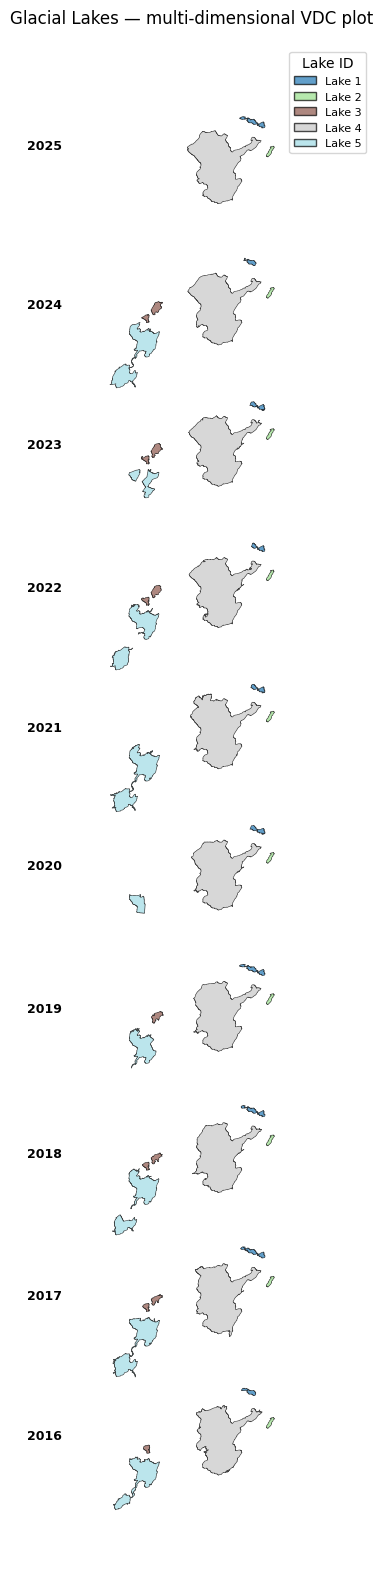

In [39]:
# --- Shear parameters (adjust to taste) ---
a, b_, d, e = 1.0, 0.3, 0.0, 1.0

# Vertical spacing between years (in CRS units = metres)
# Increase if polygons overlap, decrease if too spread out
Y_SPACING = 15_000

all_years = sorted(temporal_face["year_ts"].unique())
year_to_idx = {yr: i + 1 for i, yr in enumerate(all_years)}

# --- Apply shear + vertical shift to each polygon ---
lakes_shear = []
for _, row in temporal_face.iterrows():
    if row["geometry"] is None or row.geometry.is_empty:
        continue
    geom = row["geometry"]
    # Apply shear
    geom_s = affine_transform(geom, [a, b_, d, e, 0, 0])
    # Shift vertically by year index
    shift_y = year_to_idx[row["year_ts"]] * Y_SPACING
    geom_shifted = affine_transform(geom_s, [1, 0, 0, 1, 0, shift_y])
    lakes_shear.append({
        "id": row["id"],
        "year_ts": row["year_ts"],
        "geometry": geom_shifted,
    })

lakes_shear_gdf = gpd.GeoDataFrame(lakes_shear, geometry="geometry")

# --- Colour mapping: one colour per lake ID ---
lake_ids_sorted = sorted(lakes_shear_gdf["id"].unique())
cmap_lakes = cm.get_cmap("tab20", len(lake_ids_sorted))
id_to_color = {lid: cmap_lakes(i) for i, lid in enumerate(lake_ids_sorted)}

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 16))

for _, row in lakes_shear_gdf.iterrows():
    color = id_to_color[row["id"]]
    gpd.GeoSeries([row["geometry"]]).plot(
        ax=ax, facecolor=color, edgecolor="black", linewidth=0.4, alpha=0.7
    )

# --- Year labels on the left ---
# Place label at the vertical centre of each year's polygons
for yr in all_years:
    sub = lakes_shear_gdf[lakes_shear_gdf["year_ts"] == yr]
    if sub.empty:
        continue
    y_label = sub["geometry"].centroid.y.mean()
    x_label = lakes_shear_gdf["geometry"].bounds["minx"].min() - 5_000
    ax.text(x_label, y_label, str(yr), fontsize=9, va="center", ha="right", fontweight="bold")

# --- Legend for lake IDs ---
legend_handles = [
    Patch(facecolor=id_to_color[lid], edgecolor="k", alpha=0.7, label=f"Lake {lid}")
    for lid in lake_ids_sorted
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Lake ID")

ax.set_title("Glacial Lakes — multi-dimensional VDC plot")
ax.axis("off")
plt.tight_layout()
plt.savefig('../data/output/glacial_lakes_VDC_plot.png', bbox_inches='tight', dpi=150, pad_inches=0)
plt.show()
plt.close()